# Linear Regression

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

## Pearson Heights Dataset

The following is a classical dataset for regression. It contains data on heights of father-adult son pairs. 

In [36]:
height = pd.read_csv("PearsonHeightData.txt", sep = r"\s+")
print(height)

      Father   Son
0       65.0  59.8
1       63.3  63.2
2       65.0  63.3
3       65.8  62.8
4       61.1  64.3
...      ...   ...
1073    67.0  70.8
1074    71.3  68.3
1075    71.8  69.3
1076    70.7  69.3
1077    70.3  67.0

[1078 rows x 2 columns]


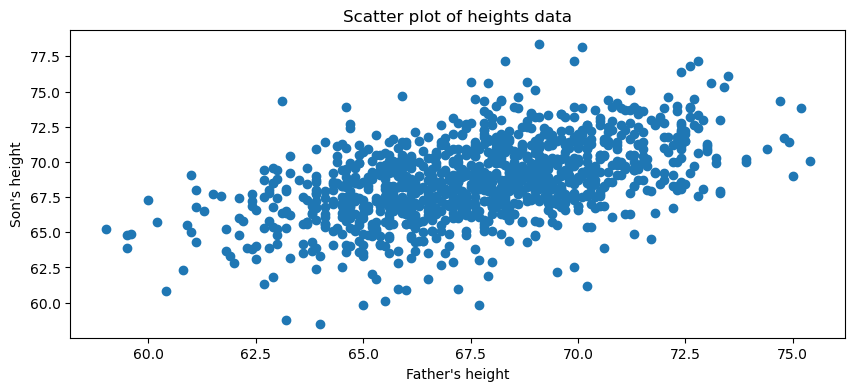

In [38]:
plt.figure(figsize = (10, 4))
plt.scatter(height["Father"], height["Son"])
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

We will fit a linear regression model with $y$ taken to be Son's height, and $x$ taken to be Father's height. Here there is only one covariate (i.e., $m = 1$) so it is called simple linear regression. We shall use the statsmodels library to fit regressions. 

In [39]:
n = height.shape[0]
X = np.column_stack([np.ones(n), height["Father"]]) #this is the X matrix (consisting of covariates and the column of ones)
y = height["Son"] #this is the y vector consisting of response values


In [40]:
linmod = sm.OLS(y, X).fit()
print(linmod.summary())


                            OLS Regression Results                            
Dep. Variable:                    Son   R-squared:                       0.251
Model:                            OLS   Adj. R-squared:                  0.250
Method:                 Least Squares   F-statistic:                     360.9
Date:                Mon, 02 Mar 2026   Prob (F-statistic):           1.27e-69
Time:                        13:24:33   Log-Likelihood:                -2489.4
No. Observations:                1078   AIC:                             4983.
Df Residuals:                    1076   BIC:                             4993.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         33.8928      1.833     18.491      0.0

In [42]:
bhat = linmod.params.values
print(bhat)
Sbhat = np.sum(linmod.resid ** 2)
m = X.shape[1] - 1 #in this case, m = 1
sighat = np.sqrt(Sbhat/(n-m-1)) #this is also called the residual standard error
print(sighat)

[33.89280054  0.51400591]
2.438134379352427


Below we plot the data along with the fitted regression line. 

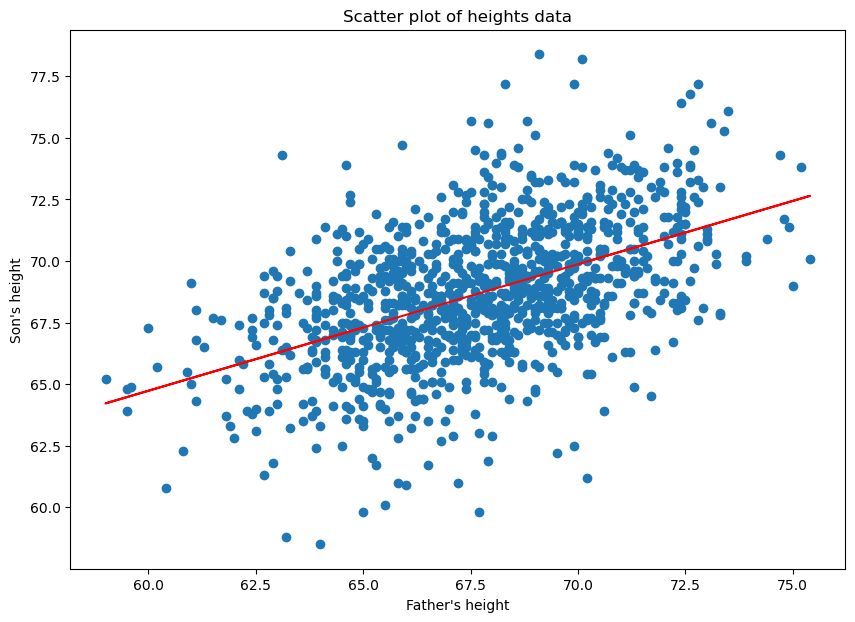

In [43]:
plt.figure(figsize = (10, 7))
plt.scatter(height["Father"], height["Son"])
x = height["Father"].values
plt.plot(x, linmod.fittedvalues, 'r')
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

To visualize the uncertainty associated with the regression line, we can draw $(\beta_0, \beta_1)$ from the posterior distribution: 
\begin{align*}
   \beta \mid \text{data} \sim t_{m+1} \left(\hat{\beta}, \hat{\sigma}^2 (X^T X)^{-1}, n - m - 1 \right). 
\end{align*}
where $\hat{\sigma}^2 = S(\hat{\beta})/(n-m-1)$. The matrix $\frac{S(\hat{\beta})}{n-m-1} (X^T X)^{-1}$ is actually calculated as part of the sm.OLS output, and can be obtained as follows:

In [44]:
m = X.shape[1] - 1 #in this case, m = 1
n = len(y)
Sigma = Sbhat / (n - m - 1) * np.linalg.inv(X.T @ X)
print(Sigma)

print(linmod.cov_params()) #this coincides with Sigma calculated above. Check out help(linmod.cov_params) for more details.


[[ 3.35950253e+00 -4.95515638e-02]
 [-4.95515638e-02  7.32071005e-04]]
          const        x1
const  3.359503 -0.049552
x1    -0.049552  0.000732


To generate observations from the $t$-distribution mentioned above, we shall use an inbuilt function from scipy:

In [45]:
from scipy.stats import multivariate_t
N = 1000 #number of samples to generate
beta_samples = multivariate_t.rvs(loc=bhat, shape=Sigma, df=n - m - 1, size=N)
print(beta_samples)

[[33.04742173  0.52666897]
 [32.94598986  0.52703271]
 [32.54037851  0.53299359]
 ...
 [32.23576553  0.54241367]
 [32.3467417   0.53697393]
 [32.04900966  0.54041803]]


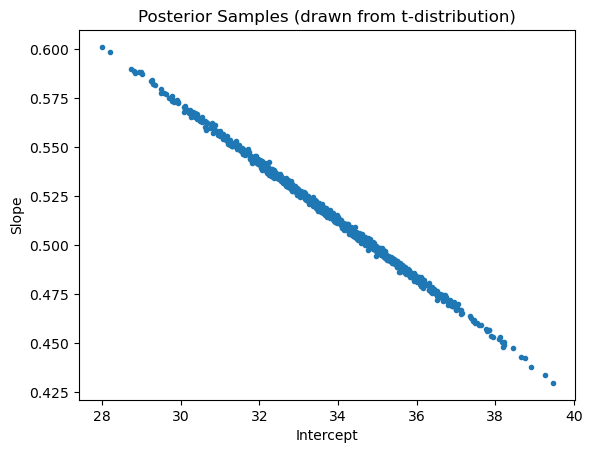

In [46]:
import matplotlib.pyplot as plt
plt.scatter(beta_samples[:,0], beta_samples[:,1], marker = '.')
plt.xlabel('Intercept')
plt.ylabel('Slope')
plt.title('Posterior Samples (drawn from t-distribution)')
plt.show()

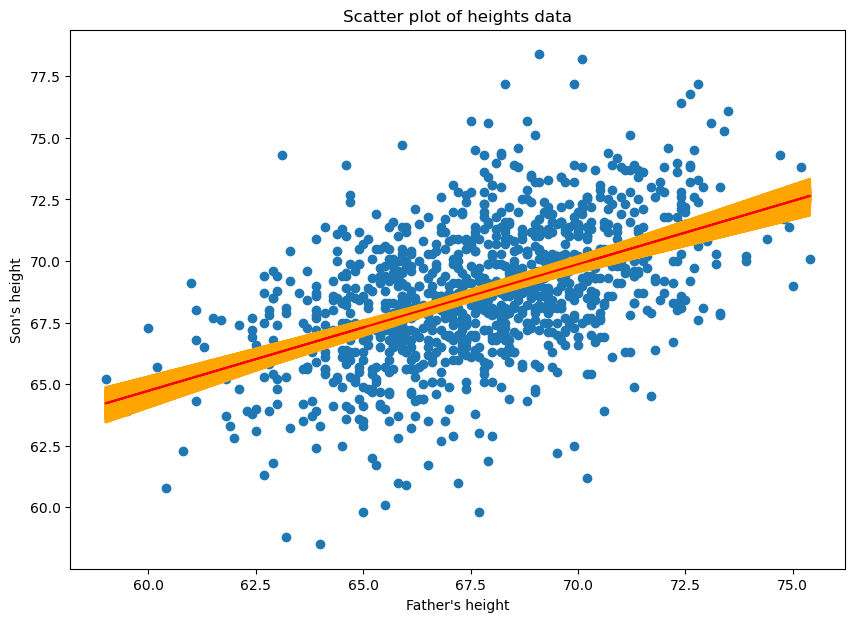

In [47]:
plt.figure(figsize = (10, 7))
plt.scatter(height["Father"], height["Son"])
x = height["Father"].values
for r in range(N): 
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(x, fvalsnew, color = 'orange')
plt.plot(x, linmod.fittedvalues, 'r')
plt.xlabel("Father's height")
plt.ylabel("Son's height")
plt.title("Scatter plot of heights data")
plt.show()

## A Simulated Dataset

Consider the following simple simulated dataset. 

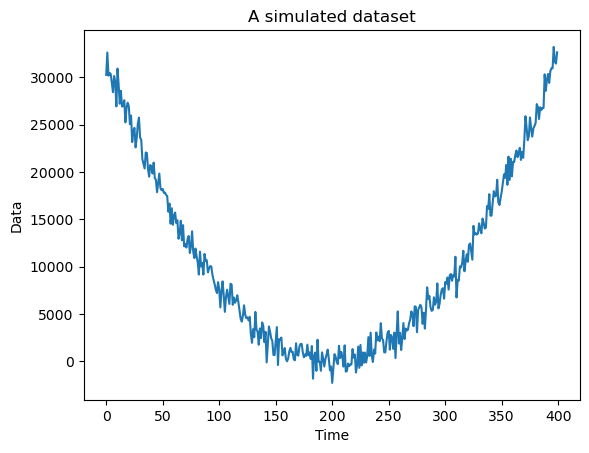

In [48]:
#A simulated dataset
n = 400
x = np.arange(1, n+1)
sig = 1000
rng = np.random.default_rng(12345)
#quadratic data with noise
y = 5 + 0.8 * ((x - (n/2)) ** 2) + rng.normal(loc = 0, scale = sig, size = n)
plt.plot(y) 
plt.xlabel("Time")
plt.ylabel("Data")
plt.title("A simulated dataset")
plt.show()

Let us fit a line (not a quadratic) to this dataset. 

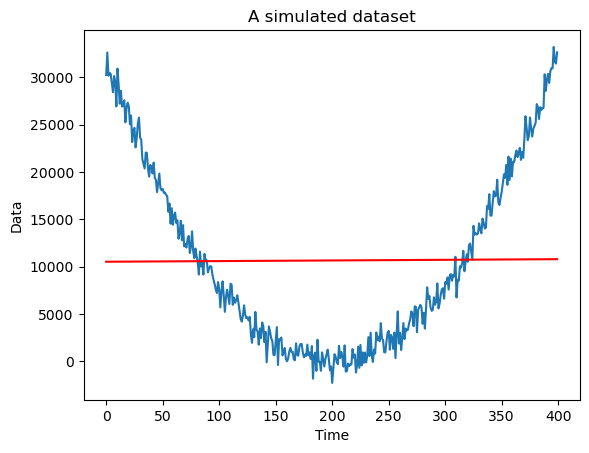

In [49]:
X = np.column_stack([np.ones(n), x])
linmod = sm.OLS(y, X).fit()
plt.plot(y)
plt.plot(linmod.fittedvalues, color = "red")
plt.xlabel("Time")
plt.ylabel("Data")
plt.title("A simulated dataset")
plt.show()

[[ 1.15441423e+04 -4.28385649e+00]
 [ 8.81460405e+03  1.03071293e+01]
 [ 1.05394896e+04  1.38910049e+00]
 ...
 [ 1.08566840e+04  5.25273171e+00]
 [ 1.11261055e+04 -5.63857139e+00]
 [ 1.10185607e+04 -7.03639275e-01]]


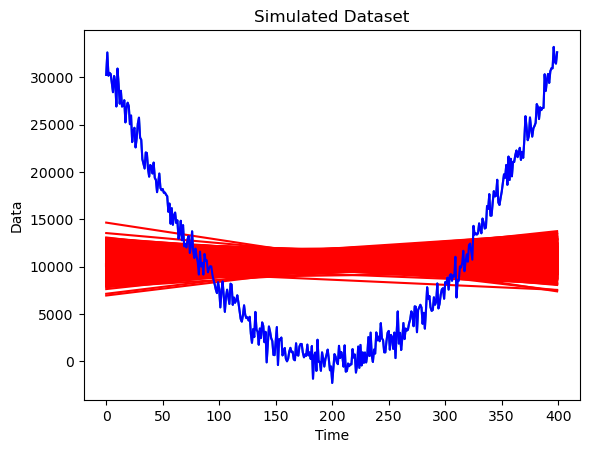

In [50]:
N = 1000 #number of samples to generate
n = X.shape[0]
m = X.shape[1] - 1
beta_samples = multivariate_t.rvs(loc=linmod.params, shape=linmod.cov_params(), df=n - m - 1, size=N)
print(beta_samples)
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
plt.plot(y, color = 'blue')
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Simulated Dataset')
plt.show()

The correct thing here is to fit a quadratic. This is done by multiple linear regression as shown below. 

In [51]:
X  = np.column_stack([np.ones(n), x, x ** 2])
quadmod = sm.OLS(y, X).fit()
print(quadmod.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.989
Method:                 Least Squares   F-statistic:                 1.849e+04
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:40:47   Log-Likelihood:                -3325.9
No. Observations:                 400   AIC:                             6658.
Df Residuals:                     397   BIC:                             6670.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         3.2e+04    149.517    214.033      0.0

[[ 3.21481039e+04 -3.22765079e+02  8.06663291e-01]
 [ 3.20425001e+04 -3.19749731e+02  7.97965584e-01]
 [ 3.21951920e+04 -3.20996981e+02  8.00088759e-01]
 ...
 [ 3.18238777e+04 -3.17068504e+02  7.93182352e-01]
 [ 3.19250922e+04 -3.18464984e+02  7.95402688e-01]
 [ 3.22866030e+04 -3.25515790e+02  8.13643963e-01]]


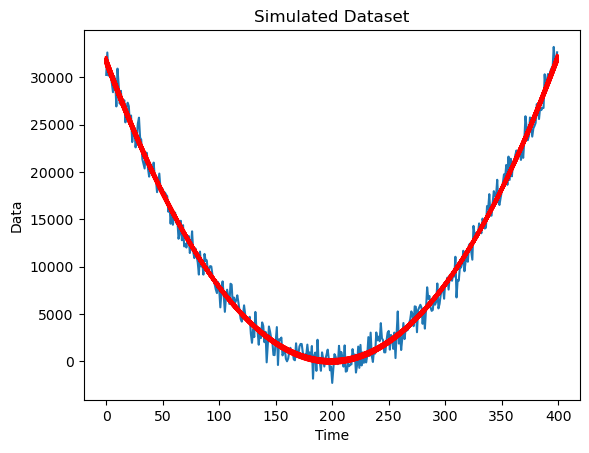

In [52]:
N = 1000 #number of samples to generate
n = X.shape[0]
m = X.shape[1] - 1
beta_samples = multivariate_t.rvs(loc=quadmod.params, shape=quadmod.cov_params(), df=n - m - 1, size=N)
print(beta_samples)
plt.plot(y)
for r in range(N):
    fvalsnew = np.dot(X, beta_samples[r])
    plt.plot(fvalsnew,  color = 'red')
#plt.plot(y, color = 'blue')
plt.xlabel('Time')
plt.ylabel('Data')
plt.title('Simulated Dataset')
plt.show()

## A Time Series Dataset (Personal Consumption Expenditures from FRED)

The following data is on personal consumption expenditures from FRED (https://fred.stlouisfed.org/series/PCEC). It measures the total amount of money that U.S. households spend on goods and services. This is a time-series record of that spending reported quarterly in billions of dollars (with seasonal adjustment). This measure is compiled by the Bureau of Economic Analysis (BEA) and is a key indicator used to track consumer demand and overall economic activity in the United States.

  observation_date     PCEC
0       1947-01-01  156.161
1       1947-04-01  160.031
2       1947-07-01  163.543
3       1947-10-01  167.672
4       1948-01-01  170.372


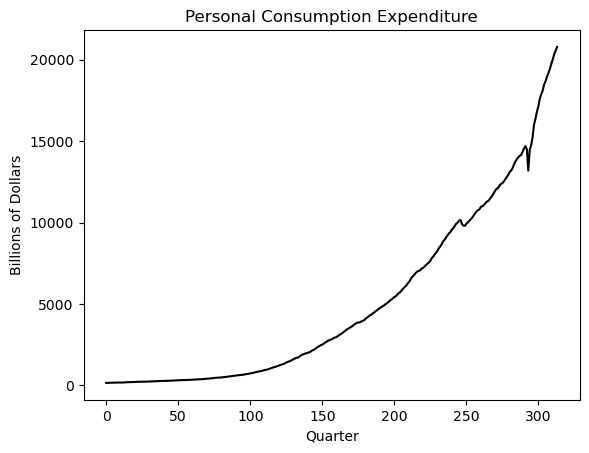

In [53]:
pcec = pd.read_csv("PCEC_30Oct2025.csv")
print(pcec.head())
y = pcec['PCEC'].to_numpy()
plt.plot(y, color = 'black')
plt.xlabel('Quarter')
plt.ylabel('Billions of Dollars')
plt.title('Personal Consumption Expenditure')
plt.show()

Let us fit the AR(1) model to this dataset. This is just linear regression with $y_t$ as response and $y_{t-1}$ as the covariate. We can fit this by manually creating $y = y_t$ and $x = y_{t-1}$ and using the sm.OLS function. 

In [54]:
p = 1
n = len(y)
yreg = y[p:] #these are the response values in the autoregression
Xmat = np.ones((n-p, 1)) #this will be the design matrix (X) in the autoregression
for j in range(1, p+1):
    col = y[p-j : n-j].reshape(-1, 1)
    Xmat = np.column_stack([Xmat, col])

armod = sm.OLS(yreg, Xmat).fit()
print(armod.params)
print(armod.summary())

[5.06629868 1.01215697]
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 6.086e+05
Date:                Mon, 02 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:55:54   Log-Likelihood:                -1949.1
No. Observations:                 313   AIC:                             3902.
Df Residuals:                     311   BIC:                             3910.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0663      9

There is also an in-built function (called AutoReg) in statsmodels for fitting AR models. We can directly use it. 

In [55]:
from statsmodels.tsa.ar_model import AutoReg
armod_sm = AutoReg(y, lags = p).fit()
print(armod_sm.summary())

                            AutoReg Model Results                             
Dep. Variable:                      y   No. Observations:                  314
Model:                     AutoReg(1)   Log Likelihood               -1949.118
Method:               Conditional MLE   S.D. of innovations            122.520
Date:                Mon, 02 Mar 2026   AIC                           3904.236
Time:                        13:56:50   BIC                           3915.475
Sample:                             1   HQIC                          3908.728
                                  314                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.0663      9.480      0.534      0.593     -13.514      23.647
y.L1           1.0122      0.001    782.656      0.000       1.010       1.015
                                    Roots           

Here are some observations comparing the above two outputs:  
1. The parameter estimates are exactly the same.
2. The regression summary gives t-scores corresponding to each parameter estimate while the AutoReg summary only gives z-scores
3. The standard errors are slightly different.

The standard errors given by the regression summary correspond to the square roots of the diagonal entries of: 
\begin{equation*}
   \hat{\sigma}^2 (X^T X)^{-1} ~~~ \text{ where } \hat{\sigma}^2 = \sqrt{\frac{\|Y - X \hat{\beta}\|^2}{n-2p-1}}
\end{equation*}
while the standard errors reported by AutoReg summary correspond to the square roots of the diagonal entries of:
\begin{equation*}
   \hat{\sigma}_{\text{MLE}}^2 (X^T X)^{-1} ~~~ \text{ where } \hat{\sigma}_{\text{MLE}}^2 = \sqrt{\frac{\|Y - X \hat{\beta}\|^2}{n-p}}
\end{equation*}